<a href="https://colab.research.google.com/github/shashankshekhar9420-creator/backprop-from-scratch/blob/main/backprop_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
class Value:

  #constructor defines the attributes and methods of the object
  def __init__(self, data, _children=(), _op=''):

    self.data = data #actual numerical value (scalar)
    self._prev=set(_children) #input nodes that produce this result (Backward perspective)
    self._op=_op #operation string ('+', '*', etc)- operation that produced this node
    self.grad = 0 #how sensitive the final output is to this node
    self._backward=lambda:None

  def __add__(self,other):
    other=other if isinstance(other,Value) else Value(other) #to make sure that both operands are Value objects
    #create output node
    out= Value(self.data+other.data, (self,other), '+')

    def _backward():
      #local derivative rule
      local_derivative=1
      #chain rule
      self.grad+=local_derivative*out.grad
      other.grad+=local_derivative*out.grad

    out._backward=_backward
    return out

  def __mul__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    #create output node
    out=Value(self.data*other.data, (self,other), '*')

    def _backward():
      local_derivative=other.data
      self.grad+=local_derivative*out.grad
      local_derivative=self.data
      other.grad+=local_derivative*out.grad

    out._backward=_backward
    return out

  def __pow__(self,other):
    assert isinstance(other, (int,float)), "only supports int/float powers"
    #create output node
    out =Value(self.data**other,(self,),f'**{other}')

    def _backward():
      #local derivative rule
      local_derivative=other*self.data**(other-1)
      #chain rule
      self.grad+=local_derivative*out.grad

    out._backward=_backward
    return out

  def relu(self):
    #forward computation
    if self.data<0:
      result=0
    else:
      result=self.data

    #create output node
    out=Value(result,(self,),'ReLU')

    def _backward():
      #local derivative rule
      if out.data>0:
        local_derivative=1
      else:
        local_derivative=0

      #chain rule
      self.grad+=local_derivative*out.grad

    out._backward=_backward
    return out


  def backward(self):
    #parents must recieve gradients only after their children have already computed theirs
    #we start from the final output becausee all gradients are: ∂(final output)/∂(node)

    topo=[]
    visited = set()

    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    #go one variable at a time and apply hte chain rule to get its gradient
    self.grad=1
    for v in reversed(topo):
      v._backward()



  def __neg__(self): # -self
    return self*-1

  def __radd__(self,other): # other + self
    return self+other

  def __sub__(self,other): # self - other
    return self+(-other)

  def __rsub__(self,other): # other - self
    return other+(-self)

  def __rmul__(self,other): # other * self
    return self*other

  def __truediv__(self,other): # self / other
    return self*(other**-1)

  def __rtruediv__(self,other): # other / self
    return other*self**-1

  def __repr__(self):
    return f"Value(data={self.data}, grad={self.grad})"

  ##for XOR
  def tanh(self):
    import math
    t = math.tanh(self.data)
    out = Value(t, (self,), 'tanh')
    def _backward():
        self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out


In [2]:
import random

#base class- because a neuron, a layer and an MLP have these properties in common
#common properties: 1.trainable parameters 2.gradients must be reset
class Module:

  def zero_grad(self):
    for p in self.parameters():
      p.grad=0

  def parameters(self):
    return []

#inherits zero_grad() and parameters()
class Neuron(Module):

  def __init__(self,nin):
    #nin: number of inputs
    self.w=[]
    for i in range(nin):
      self.w.append(Value(random.uniform(-1,1)))
    self.b=Value(random.uniform(-1,1))

  def __call__(self,x):
      act=self.b
      for wi,xi in zip(self.w,x):
          act+=wi*xi
      #return act.relu()
      return act.tanh()

  def parameters(self):
      return self.w + [self.b]

  def __repr__(self):
      return f"ReLU Neuron({len(self.w)})"

class Layer(Module):

  def __init__(self,nin,nout):
    self.neurons=[]
    for i in range(nout):
      self.neurons.append(Neuron(nin))

  def __call__(self,x):
    out=[]
    for n in self.neurons:
      out.append(n(x))
    return out

  def parameters(self):
    params=[]

    for n in self.neurons:
      params.extend(n.parameters())

    return params

  def __repr__(self):
    s="Layer: \n"
    for n in self.neurons:
      s+=str(n)+"\n"

    return s


class MLP(Module):

  def __init__(self,nin,nouts):
    #sz=[no. of inputs, layer one with ? neurons, layer two with ? neurons, ....]
    sz=[nin]+nouts

    self.layers=[]
    for i in range(len(sz)-1):
      self.layers.append(Layer(sz[i],sz[i+1]))

  def __call__(self,x):
      for layer in self.layers:
        x=layer(x)
      return x

  def parameters(self):
      params=[]
      for layer in self.layers:
        params.extend(layer.parameters())
      return params

  def __repr__(self):
    s="MLP:\n"
    for layer in self.layers:
      s+=str(layer)+"\n"
    return s

In [3]:
# XOR dataset
X = [[0,0],[0,1],[1,0],[1,1]]
y = [0,1,1,0]

# model
model = MLP(2, [4, 1])

for epoch in range(2000):
    ypred = [model(x)[0] for x in X]
    loss = sum((yp - Value(yt))**2 for yp,yt in zip(ypred,y))

    model.zero_grad()
    loss.backward()

    for p in model.parameters():
        p.data -= 0.05 * p.grad  # slower lr

    if epoch % 100 == 0:
        print(f"epoch {epoch} loss {loss.data:.4f}")

# check predictions
print([round(model(x)[0].data) for x in X])  # should be [0,1,1,0]

epoch 0 loss 1.8404
epoch 100 loss 0.1839
epoch 200 loss 0.0341
epoch 300 loss 0.0159
epoch 400 loss 0.0099
epoch 500 loss 0.0071
epoch 600 loss 0.0055
epoch 700 loss 0.0044
epoch 800 loss 0.0037
epoch 900 loss 0.0032
epoch 1000 loss 0.0028
epoch 1100 loss 0.0025
epoch 1200 loss 0.0022
epoch 1300 loss 0.0020
epoch 1400 loss 0.0018
epoch 1500 loss 0.0017
epoch 1600 loss 0.0015
epoch 1700 loss 0.0014
epoch 1800 loss 0.0013
epoch 1900 loss 0.0013
[0, 1, 1, 0]


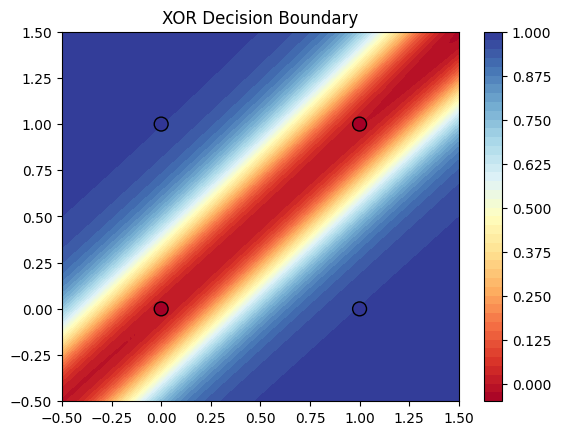

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# grid
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,100), np.linspace(-0.5,1.5,100))
grid = [[xx[i,j], yy[i,j]] for i in range(100) for j in range(100)]

# predict
Z = [model([x,y])[0].data for x,y in grid]
Z = np.array(Z).reshape(100,100)

# plot
plt.contourf(xx, yy, Z, levels=50, cmap='RdYlBu')
plt.colorbar()
plt.scatter([0,0,1,1],[0,1,0,1], c=[0,1,1,0], cmap='RdYlBu', edgecolors='black', s=100)
plt.title("XOR Decision Boundary")
plt.show()